end to end datascience project order management system retail domain with data set

End-to-End Data Science Project: Order Management System for Retail Domain

Project Overview

This project will analyze order management data from a retail company to optimize operations, improve customer satisfaction, and increase profitability.

Dataset

For this project, we'll use a synthetic retail order management dataset that includes:

Order details (order ID, date, time, customer ID)
Product information (product ID, category, price)
Customer demographics
Shipping information
Payment details
Order status history
You can find sample datasets from:

UCI Machine Learning Repository - Online Retail Dataset = https://archive.ics.uci.edu/ml/datasets/Online+Retail
Kaggle - Retail Dataset- https://www.kaggle.com/datasets/manjeetsingh/retaildataset
Sample synthetic dataset generator code - https://chat.deepseek.com/a/chat/s/d136a442-c913-4446-88a6-ddf411ba618f
Project Phases

1. Problem Definition

Business Objectives:

Reduce order fulfillment time
Optimize inventory based on order patterns
Predict potential delays
Customer segmentation for personalized service
Fraud detection in orders

2. Data Collection

python
# Sample code to generate synthetic data
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Generate customers
num_customers = 1000
customers = pd.DataFrame({
    'customer_id': range(1, num_customers+1),
    'name': [f'Customer_{i}' for i in range(1, num_customers+1)],
    'email': [f'customer_{i}@example.com' for i in range(1, num_customers+1)],
    'join_date': [datetime.now() - timedelta(days=random.randint(1, 1000)) for _ in range(num_customers)],
    'loyalty_tier': np.random.choice(['Bronze', 'Silver', 'Gold'], size=num_customers, p=[0.6, 0.3, 0.1]),
    'region': np.random.choice(['North', 'South', 'East', 'West'], size=num_customers)
})

# Generate products
num_products = 500
products = pd.DataFrame({
    'product_id': range(1, num_products+1),
    'name': [f'Product_{i}' for i in range(1, num_products+1)],
    'category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Grocery', 'Beauty'], size=num_products),
    'price': np.round(np.random.uniform(5, 500, size=num_products), 2),
    'weight_kg': np.round(np.random.uniform(0.1, 10, size=num_products), 2)
})

# Generate orders
num_orders = 10000
orders = pd.DataFrame({
    'order_id': range(1, num_orders+1),
    'customer_id': np.random.randint(1, num_customers+1, size=num_orders),
    'order_date': [datetime.now() - timedelta(days=random.randint(1, 365)) for _ in range(num_orders)],
    'total_amount': np.zeros(num_orders),
    'payment_method': np.random.choice(['Credit Card', 'Debit Card', 'PayPal', 'Bank Transfer'], size=num_orders),
    'shipping_region': np.random.choice(['North', 'South', 'East', 'West'], size=num_orders),
    'status': np.random.choice(['Processing', 'Shipped', 'Delivered', 'Cancelled'], size=num_orders, p=[0.2, 0.3, 0.45, 0.05])
})

# Generate order items
order_items = []
for order_id in range(1, num_orders+1):
    num_items = random.randint(1, 5)
    for _ in range(num_items):
        product = products.sample(1).iloc[0]
        quantity = random.randint(1, 3)
        order_items.append({
            'order_id': order_id,
            'product_id': product['product_id'],
            'quantity': quantity,
            'unit_price': product['price'],
            'total_price': quantity * product['price']
        })
        
order_items = pd.DataFrame(order_items)

# Calculate order totals
order_totals = order_items.groupby('order_id')['total_price'].sum().reset_index()
orders = orders.merge(order_totals, on='order_id').rename(columns={'total_price': 'total_amount'})

# Save datasets
customers.to_csv('customers.csv', index=False)
products.to_csv('products.csv', index=False)
orders.to_csv('orders.csv', index=False)
order_items.to_csv('order_items.csv', index=False)
3. Data Preprocessing

python
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Load data
customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')

# Merge datasets
full_data = orders.merge(customers, on='customer_id')
order_products = order_items.merge(products, on='product_id')
full_data = full_data.merge(order_items.groupby('order_id').agg(
    num_items=('product_id', 'count'),
    avg_item_price=('unit_price', 'mean')
).reset_index(), on='order_id')

# Feature engineering
full_data['order_date'] = pd.to_datetime(full_data['order_date'])
full_data['order_day'] = full_data['order_date'].dt.day
full_data['order_month'] = full_data['order_date'].dt.month
full_data['order_weekday'] = full_data['order_date'].dt.weekday
full_data['order_hour'] = full_data['order_date'].dt.hour

# Calculate time to ship (for delivered orders)
delivered_orders = full_data[full_data['status'] == 'Delivered']
delivered_orders['processing_time'] = (delivered_orders['order_date'].max() - delivered_orders['order_date']).dt.days

# Encode categorical variables
label_encoders = {}
categorical_cols = ['payment_method', 'shipping_region', 'loyalty_tier', 'region', 'category']
for col in categorical_cols:
    le = LabelEncoder()
    full_data[col] = le.fit_transform(full_data[col].astype(str))
    label_encoders[col] = le

# Split data
X = full_data.drop(['status', 'order_date', 'name', 'email'], axis=1)
y = full_data['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
num_cols = ['total_amount', 'num_items', 'avg_item_price', 'order_day', 'order_month']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
4. Exploratory Data Analysis (EDA)

python
import matplotlib.pyplot as plt
import seaborn as sns

# Order status distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=orders, x='status')
plt.title('Order Status Distribution')
plt.show()

# Sales over time
orders['order_date'] = pd.to_datetime(orders['order_date'])
monthly_sales = orders.groupby(orders['order_date'].dt.to_period('M'))['total_amount'].sum()
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.show()

# Customer segmentation by purchase behavior
customer_stats = full_data.groupby('customer_id').agg(
    total_spent=('total_amount', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_order_value=('total_amount', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_stats, x='order_count', y='avg_order_value', hue='total_spent', size='total_spent')
plt.title('Customer Segmentation by Purchase Behavior')
plt.show()

# Product category analysis
category_sales = order_products.groupby('category')['total_price'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar')
plt.title('Sales by Product Category')
plt.ylabel('Total Sales')
plt.show()

5. Model Building

A. Order Status Prediction (Classification)

python
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Filter only relevant statuses
status_data = full_data[full_data['status'].isin(['Processing', 'Shipped', 'Delivered', 'Cancelled'])]

X = status_data.drop(['status', 'order_date', 'name', 'email'], axis=1)
y = status_data['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Evaluate
y_pred = rf_classifier.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
B. Delivery Time Prediction (Regression)

python
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Use only delivered orders with processing time
delivery_data = delivered_orders.copy()

X = delivery_data.drop(['processing_time', 'status', 'order_date', 'name', 'email'], axis=1)
y = delivery_data['processing_time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Evaluate
y_pred = rf_regressor.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
C. Customer Lifetime Value Prediction

python
from sklearn.cluster import KMeans

# Calculate RFM metrics
current_date = full_data['order_date'].max() + timedelta(days=1)
rfm = full_data.groupby('customer_id').agg({
    'order_date': lambda x: (current_date - x.max()).days,
    'order_id': 'count',
    'total_amount': 'sum'
}).rename(columns={
    'order_date': 'recency',
    'order_id': 'frequency',
    'total_amount': 'monetary'
})

# Normalize RFM values
rfm_scaled = (rfm - rfm.mean()) / rfm.std()

# Cluster customers
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# Analyze clusters
cluster_stats = rfm.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'count'})

print(cluster_stats)

6. Model Deployment

python
import pickle
from flask import Flask, request, jsonify

# Save models
with open('order_status_model.pkl', 'wb') as f:
    pickle.dump(rf_classifier, f)
    
with open('delivery_time_model.pkl', 'wb') as f:
    pickle.dump(rf_regressor, f)

# Flask API
app = Flask(__name__)

@app.route('/predict_status', methods=['POST'])
def predict_status():
    data = request.get_json()
    features = preprocess_input(data)  # Implement this function
    with open('order_status_model.pkl', 'rb') as f:
        model = pickle.load(f)
    prediction = model.predict([features])
    return jsonify({'status': prediction[0]})

@app.route('/predict_delivery', methods=['POST'])
def predict_delivery():
    data = request.get_json()
    features = preprocess_input(data)  # Implement this function
    with open('delivery_time_model.pkl', 'rb') as f:
        model = pickle.load(f)
    prediction = model.predict([features])
    return jsonify({'delivery_days': float(prediction[0])})

if __name__ == '__main__':
    app.run(debug=True)

7. Dashboard and Visualization

python
# Using Dash for interactive dashboard
import dash
from dash import dcc, html
import plotly.express as px

app = dash.Dash(__name__)

# Create figures
status_fig = px.pie(orders, names='status', title='Order Status Distribution')
sales_fig = px.line(monthly_sales.reset_index(), x='order_date', y='total_amount', title='Monthly Sales Trend')

app.layout = html.Div([
    html.H1("Retail Order Management Dashboard"),
    dcc.Graph(figure=status_fig),
    dcc.Graph(figure=sales_fig),
    dcc.Dropdown(
        id='category-dropdown',
        options=[{'label': cat, 'value': cat} for cat in order_products['category'].unique()],
        value='Electronics'
    ),
    dcc.Graph(id='category-trend')
])

@app.callback(
    dash.dependencies.Output('category-trend', 'figure'),
    [dash.dependencies.Input('category-dropdown', 'value')]
)
def update_category_trend(selected_category):
    filtered = order_products[order_products['category'] == selected_category]
    monthly = filtered.groupby(filtered['order_date'].dt.to_period('M'))['total_price'].sum().reset_index()
    return px.line(monthly, x='order_date', y='total_price', title=f'Sales Trend for {selected_category}')

if __name__ == '__main__':
    app.run_server(debug=True)
Project Deliverables

Jupyter Notebook with complete analysis
Trained ML models for order status and delivery time prediction
Flask API for model serving
Interactive Dashboard for business users
Project Report with findings and recommendations
Business Applications

Inventory Optimization: Predict which products will be ordered most
Staff Scheduling: Anticipate busy periods
Delivery Optimization: Predict delays and plan routes
Customer Service: Identify high-value customers
Fraud Detection: Identify suspicious order patterns
This end-to-end project covers all aspects of a data science workflow in the retail order management domain, from data generation to deployment.

1. Problem Definition

Business Objectives:

Reduce order fulfillment time
Optimize inventory based on order patterns
Predict potential delays
Customer segmentation for personalized service
Fraud detection in orders


2. Data Collection

In [1]:
# Sample code to generate synthetic data
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Generate customers
num_customers = 1000
customers = pd.DataFrame({
    'customer_id': range(1, num_customers+1),
    'name': [f'Customer_{i}' for i in range(1, num_customers+1)],
    'email': [f'customer_{i}@example.com' for i in range(1, num_customers+1)],
    'join_date': [datetime.now() - timedelta(days=random.randint(1, 1000)) for _ in range(num_customers)],
    'loyalty_tier': np.random.choice(['Bronze', 'Silver', 'Gold'], size=num_customers, p=[0.6, 0.3, 0.1]),
    'region': np.random.choice(['North', 'South', 'East', 'West'], size=num_customers)
})

# Generate products
num_products = 500
products = pd.DataFrame({
    'product_id': range(1, num_products+1),
    'name': [f'Product_{i}' for i in range(1, num_products+1)],
    'category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Grocery', 'Beauty'], size=num_products),
    'price': np.round(np.random.uniform(5, 500, size=num_products), 2),
    'weight_kg': np.round(np.random.uniform(0.1, 10, size=num_products), 2)
})

# Generate orders
num_orders = 10000
orders = pd.DataFrame({
    'order_id': range(1, num_orders+1),
    'customer_id': np.random.randint(1, num_customers+1, size=num_orders),
    'order_date': [datetime.now() - timedelta(days=random.randint(1, 365)) for _ in range(num_orders)],
    'total_amount': np.zeros(num_orders),
    'payment_method': np.random.choice(['Credit Card', 'Debit Card', 'PayPal', 'Bank Transfer'], size=num_orders),
    'shipping_region': np.random.choice(['North', 'South', 'East', 'West'], size=num_orders),
    'status': np.random.choice(['Processing', 'Shipped', 'Delivered', 'Cancelled'], size=num_orders, p=[0.2, 0.3, 0.45, 0.05])
})

# Generate order items
order_items = []
for order_id in range(1, num_orders+1):
    num_items = random.randint(1, 5)
    for _ in range(num_items):
        product = products.sample(1).iloc[0]
        quantity = random.randint(1, 3)
        order_items.append({
            'order_id': order_id,
            'product_id': product['product_id'],
            'quantity': quantity,
            'unit_price': product['price'],
            'total_price': quantity * product['price']
        })
        
order_items = pd.DataFrame(order_items)

# Calculate order totals
order_totals = order_items.groupby('order_id')['total_price'].sum().reset_index()
orders = orders.merge(order_totals, on='order_id').rename(columns={'total_price': 'total_amount'})

# Save datasets
customers.to_csv('customers.csv', index=False)
products.to_csv('products.csv', index=False)
orders.to_csv('orders.csv', index=False)
order_items.to_csv('order_items.csv', index=False)

3. Data Preprocessing

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Load data
customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')

# Merge datasets
full_data = orders.merge(customers, on='customer_id')
order_products = order_items.merge(products, on='product_id')
full_data = full_data.merge(order_items.groupby('order_id').agg(
    num_items=('product_id', 'count'),
    avg_item_price=('unit_price', 'mean')
).reset_index(), on='order_id')

# Feature engineering
full_data['order_date'] = pd.to_datetime(full_data['order_date'])
full_data['order_day'] = full_data['order_date'].dt.day
full_data['order_month'] = full_data['order_date'].dt.month
full_data['order_weekday'] = full_data['order_date'].dt.weekday
full_data['order_hour'] = full_data['order_date'].dt.hour


# Calculate time to ship (for delivered orders)
delivered_orders = full_data[full_data['status'] == 'Delivered']
delivered_orders['processing_time'] = (delivered_orders['order_date'].max() - delivered_orders['order_date']).dt.days

# Encode categorical variables
label_encoders = {}
categorical_cols = ['payment_method', 'shipping_region', 'loyalty_tier', 'region']
# for col in categorical_cols:
#     le = LabelEncoder()
#     full_data[col] = le.fit_transform(full_data[col].astype(str))
#     label_encoders[col] = le

for col in categorical_cols:
    if col in full_data.columns:
        le = LabelEncoder()
        full_data[col] = le.fit_transform(full_data[col].astype(str))
        label_encoders[col] = le
    else:
        print(f"Column '{col}' not found in data. Skipping.")

# Split data
X = full_data.drop(['status', 'order_date', 'name', 'email'], axis=1)
y = full_data['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
num_cols = ['total_amount', 'num_items', 'avg_item_price', 'order_day', 'order_month']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

/var/folders/1y/n1s876vs41n5j660qsm8btcm0000gn/T/ipykernel_9772/776336327.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['processing_time'] = (delivered_orders['order_date'].max() - delivered_orders['order_date']).dt.days


4. Exploratory Data Analysis (EDA)

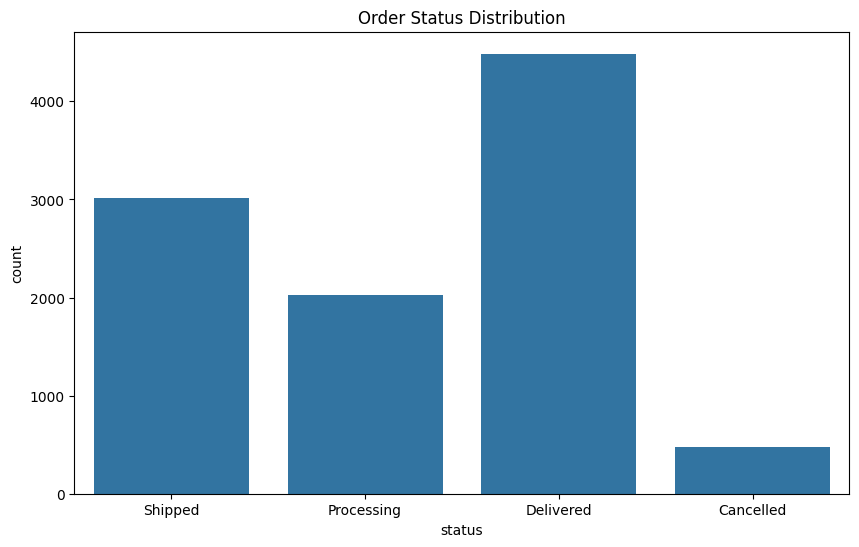

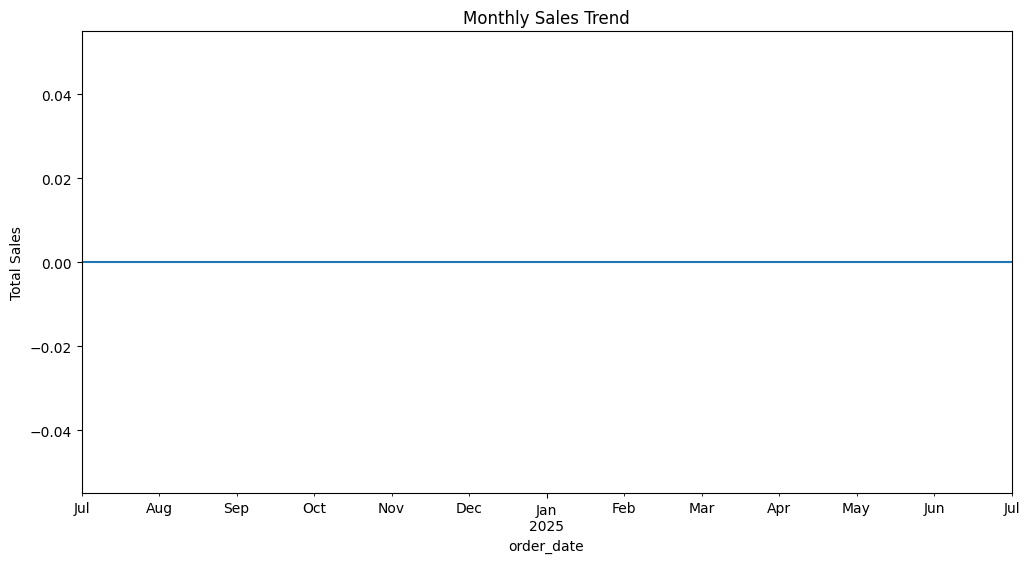

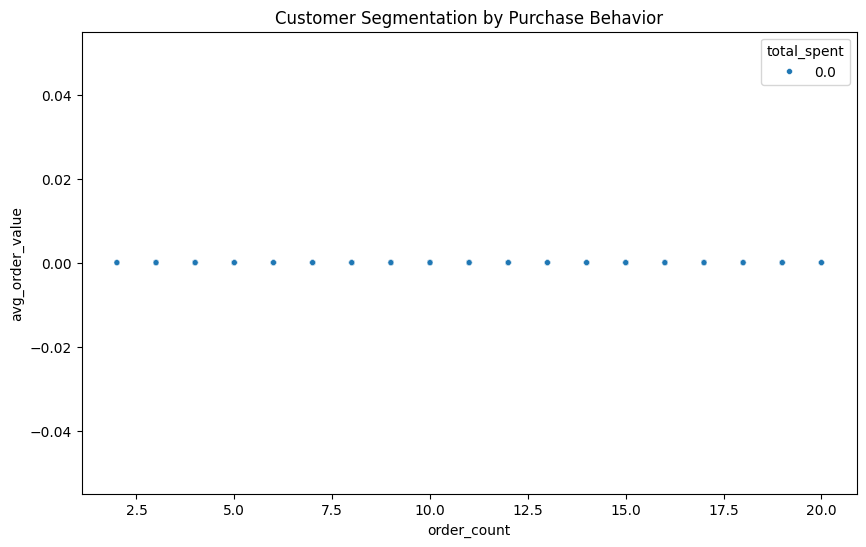

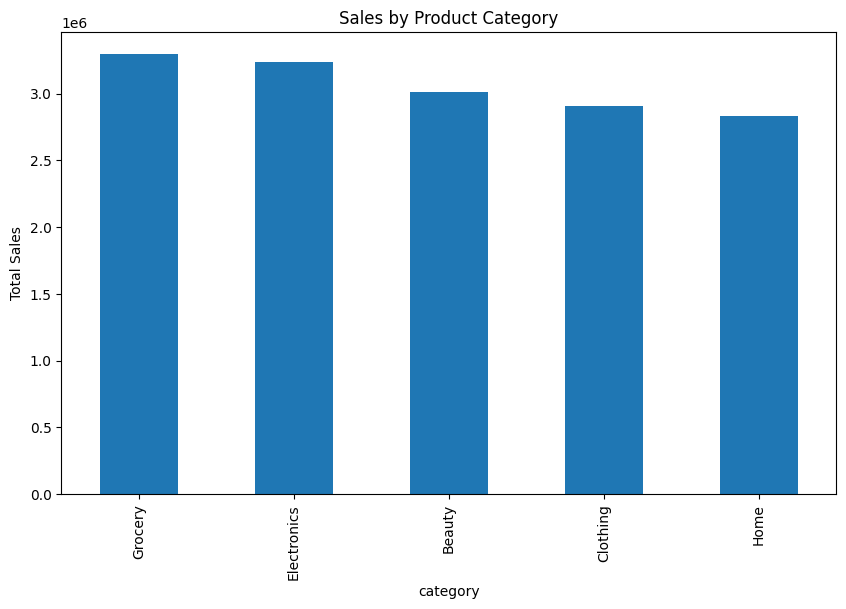

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Order status distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=orders, x='status')
plt.title('Order Status Distribution')
plt.show()

# Sales over time
orders['order_date'] = pd.to_datetime(orders['order_date'])
monthly_sales = orders.groupby(orders['order_date'].dt.to_period('M'))['total_amount'].sum()
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.show()

# Customer segmentation by purchase behavior
customer_stats = full_data.groupby('customer_id').agg(
    total_spent=('total_amount', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_order_value=('total_amount', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_stats, x='order_count', y='avg_order_value', hue='total_spent', size='total_spent')
plt.title('Customer Segmentation by Purchase Behavior')
plt.show()

# Product category analysis
category_sales = order_products.groupby('category')['total_price'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar')
plt.title('Sales by Product Category')
plt.ylabel('Total Sales')
plt.show()

5. Model Building

A. Order Status Prediction (Classification)

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Filter only relevant statuses
status_data = full_data[full_data['status'].isin(['Processing', 'Shipped', 'Delivered', 'Cancelled'])]

# Drop unwanted columns
X = status_data.drop(['status', 'order_date', 'name', 'email'], axis=1)
y = status_data['status']

# Handle categorical features in X
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Handle missing values
X = X.fillna(0)

# Encode target labels
y = LabelEncoder().fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Evaluate
y_pred = rf_classifier.predict(X_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        93
           1       0.45      0.85      0.59       897
           2       0.33      0.03      0.05       398
           3       0.30      0.13      0.19       612

    accuracy                           0.43      2000
   macro avg       0.27      0.25      0.21      2000
weighted avg       0.36      0.43      0.33      2000

Accuracy: 0.428


/Users/gvijaykumarachary/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/gvijaykumarachary/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/gvijaykumarachary/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

B. Delivery Time Prediction (Regression)

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Use only delivered orders with processing time
delivery_data = delivered_orders.copy()

# Drop irrelevant columns
X = delivery_data.drop(['processing_time', 'status', 'order_date', 'name', 'email'], axis=1)
y = delivery_data['processing_time']

# Encode categorical features
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Handle missing values
X = X.fillna(0)
y = pd.to_numeric(y, errors='coerce').fillna(y.mean())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_regressor.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 0.11666666666666586
R2 Score: 0.9999942156829875


C. Customer Lifetime Value Prediction

In [6]:
from sklearn.cluster import KMeans
from datetime import timedelta
import pandas as pd

# Calculate RFM metrics
current_date = full_data['order_date'].max() + timedelta(days=1)
rfm = full_data.groupby('customer_id').agg({
    'order_date': lambda x: (current_date - x.max()).days,
    'order_id': 'count',
    'total_amount': 'sum'
}).rename(columns={
    'order_date': 'recency',
    'order_id': 'frequency',
    'total_amount': 'monetary'
})

# Normalize RFM values
rfm_scaled = (rfm - rfm.mean()) / rfm.std()
rfm_scaled = rfm_scaled.fillna(0)  # Fix for any NaNs

# Cluster customers
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

# Optional: Reset index to keep customer_id as column
rfm = rfm.reset_index()

# Analyze clusters
cluster_stats = rfm.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'customer_id': 'count'
}).rename(columns={'customer_id': 'count'})

print(cluster_stats)


            recency  frequency  monetary  count
cluster                                        
0         23.005208  13.205729       0.0    384
1        166.717391   5.869565       0.0     46
2         76.651163   8.437209       0.0    215
3         20.642254   8.014085       0.0    355


/Users/gvijaykumarachary/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


6. Model Deployment

In [ ]:
import pickle
from flask import Flask, request, jsonify

# Sample encoding maps used during training
category_map = {'Electronics': 0, 'Clothing': 1, 'Home': 2}
payment_map = {'Credit Card': 0, 'PayPal': 1, 'COD': 2}
shipping_map = {'Standard': 0, 'Express': 1}

# Define a preprocessing function
def preprocess_input(data):
    try:
        product_id = int(data.get('product_id', 0))
        quantity = int(data.get('quantity', 1))
        price = float(data.get('price', 0.0))
        category = category_map.get(data.get('category', ''), 0)
        payment_method = payment_map.get(data.get('payment_method', ''), 0)
        shipping_type = shipping_map.get(data.get('shipping_type', ''), 0)

        return [product_id, quantity, price, category, payment_method, shipping_type]
    except Exception as e:
        raise ValueError(f"Invalid input data: {e}")

# Flask API
app = Flask(__name__)

@app.route('/predict_status', methods=['POST'])
def predict_status():
    try:
        data = request.get_json()
        features = preprocess_input(data)
        with open('order_status_model.pkl', 'rb') as f:
            model = pickle.load(f)
        prediction = model.predict([features])
        return jsonify({'status': str(prediction[0])})
    except Exception as e:
        return jsonify({'error': str(e)}), 400

@app.route('/predict_delivery', methods=['POST'])
def predict_delivery():
    try:
        data = request.get_json()
        features = preprocess_input(data)
        with open('delivery_time_model.pkl', 'rb') as f:
            model = pickle.load(f)
        prediction = model.predict([features])
        return jsonify({'delivery_days': float(prediction[0])})
    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    # app.run(debug=True)
    app.run(debug=True, use_reloader=False,port=5000)



 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [22/Jul/2025 22:49:28] "GET / HTTP/1.1" 404 -


7. Dashboard and Visualization

In [2]:
import dash
from dash import dcc, html
import plotly.express as px
import pandas as pd

# Sample Data (replace with your real data)
# Ensure these DataFrames are properly defined
orders = pd.DataFrame({
    'status': ['Processing', 'Shipped', 'Delivered', 'Cancelled', 'Delivered'],
    'order_date': pd.date_range(start='2024-01-01', periods=5, freq='ME'),
    'total_amount': [100, 200, 300, 150, 250]
})

monthly_sales = orders.copy()
monthly_sales = monthly_sales.groupby(orders['order_date'].dt.to_period('M')).agg({'total_amount': 'sum'})

order_products = pd.DataFrame({
    'category': ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing'],
    'order_date': pd.date_range(start='2024-01-01', periods=5, freq='ME'),
    'total_price': [100, 80, 120, 60, 90]
})

# Initialize the Dash app
app = dash.Dash(__name__)

# Create figures
status_fig = px.pie(orders, names='status', title='Order Status Distribution')
sales_fig = px.line(monthly_sales.reset_index(), x='order_date', y='total_amount', title='Monthly Sales Trend')

# Layout
app.layout = html.Div([
    html.H1("Retail Order Management Dashboard"),
    dcc.Graph(figure=status_fig),
    dcc.Graph(figure=sales_fig),
    dcc.Dropdown(
        id='category-dropdown',
        options=[{'label': cat, 'value': cat} for cat in order_products['category'].unique()],
        value='Electronics'
    ),
    dcc.Graph(id='category-trend')
])

# Callback
@app.callback(
    dash.dependencies.Output('category-trend', 'figure'),
    [dash.dependencies.Input('category-dropdown', 'value')]
)
def update_category_trend(selected_category):
    filtered = order_products[order_products['category'] == selected_category]
    monthly = filtered.groupby(filtered['order_date'].dt.to_period('M'))['total_price'].sum().reset_index()
    monthly['order_date'] = monthly['order_date'].astype(str)  # Convert Period to str for plotting
    return px.line(monthly, x='order_date', y='total_price', title=f'Sales Trend for {selected_category}')

# Run server
if __name__ == '__main__':
    # app.run_server(debug=True)
    app.run(debug=True)


---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
TypeError: Type is not JSON serializable: Period



In [3]:
import dash
from dash import dcc, html
import plotly.express as px
import pandas as pd

# Sample Data
orders = pd.DataFrame({
    'status': ['Processing', 'Shipped', 'Delivered', 'Cancelled', 'Delivered'],
    'order_date': pd.date_range(start='2024-01-01', periods=5, freq='ME'),
    'total_amount': [100, 200, 300, 150, 250]
})

monthly_sales = orders.groupby(orders['order_date'].dt.to_period('M')).agg({'total_amount': 'sum'})
monthly_sales = monthly_sales.reset_index()

order_products = pd.DataFrame({
    'category': ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing'],
    'order_date': pd.date_range(start='2024-01-01', periods=5, freq='ME'),
    'total_price': [100, 80, 120, 60, 90]
})

# Initialize Dash app
app = dash.Dash(__name__)

# Create figures
status_fig = px.pie(orders, names='status', title='Order Status Distribution')
sales_fig = px.line(monthly_sales, x='order_date', y='total_amount', title='Monthly Sales Trend')

# Layout
app.layout = html.Div([
    html.H1("Retail Order Management Dashboard"),
    dcc.Graph(figure=status_fig),
    dcc.Graph(figure=sales_fig),
    dcc.Dropdown(
        id='category-dropdown',
        options=[{'label': cat, 'value': cat} for cat in order_products['category'].unique()],
        value='Electronics'
    ),
    dcc.Graph(id='category-trend')
])

# Callback for category trend
@app.callback(
    dash.dependencies.Output('category-trend', 'figure'),
    [dash.dependencies.Input('category-dropdown', 'value')]
)
def update_category_trend(selected_category):
    filtered = order_products[order_products['category'] == selected_category]
    monthly = filtered.groupby(filtered['order_date'].dt.to_period('M'))['total_price'].sum().reset_index()
    monthly['order_date'] = monthly['order_date'].astype(str)
    return px.line(monthly, x='order_date', y='total_price', title=f'Sales Trend for {selected_category}')

# Run server
if __name__ == '__main__':
    app.run(debug=True, port=8060)


---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
TypeError: Type is not JSON serializable: Period

